In [1]:
%load_ext IPython.extensions.autoreload
%autoreload 2

import warnings
warnings.filterwarnings('ignore')

In [4]:
import sys
sys.path.append('../../')
from model import FinData
from model import train_valid_test_split
from model import CatboostFinModel
from model import fbeta_metric_long, precision_long, recall_long, fbeta_metric_short, precision_short, recall_short

import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import pandas as pd

/Users/naburkova/repos/prices-predictions-1/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Выгружаем лонг и шорт данные 

In [97]:
# Лонг

import pandas as pd
import datetime as dt
import xgboost as xgb

companies_names = ['Positive'] # Bashneft, Sber, Positive, Whoosh, MMK
dfs = ["../../datasets/" + stock + '_1_min.csv' for stock in companies_names]

cutoff_time = dt.datetime(2024, 2, 1)
start_time = dt.datetime(2024, 5, 1)
end_time = dt.datetime(2024, 12, 31)

for i in range(len(dfs)):
    res = pd.DataFrame()
    findata = FinData(dfs[i])
    findata.restrict_time_down(cutoff_time)
    findata.insert_all()

    cat_feats = findata.cat_features
    num_feats = findata.numeric_features
    target = 'direction_binary_0'
    
    curr_time = start_time
    company_name = companies_names[i]

    while curr_time < end_time:
        data = findata.df
        train_df = data[(data.utc >= curr_time - dt.timedelta(days=35)) & (data.utc <= curr_time - dt.timedelta(days=5))]
        val_df = data[(data.utc > curr_time - dt.timedelta(days=5)) & (data.utc <= curr_time)]
        test_df = data[(data.utc > curr_time) & (data.utc <= curr_time + dt.timedelta(days=5))]
        train_sd, val_sd, test_sd = train_df["utc"].iloc[0], val_df["utc"].iloc[0], test_df["utc"].iloc[0]
        train_ed, val_ed, test_ed = train_df["utc"].iloc[-1], val_df["utc"].iloc[-1], test_df["utc"].iloc[-1]
        print(f"Начало тренировочного периода: {train_sd}. Конец тренировочного периода: {train_ed} \n \
                    Начало валидационного периода: {val_sd}. Конец валидационного периода: {val_ed} \n \
                    Начало тестового периода: {test_sd}. Конец тестового периода: {test_ed} \n ")
        X_train, y_train = train_df[cat_feats + num_feats], train_df[target]
        X_val, y_val = val_df[cat_feats + num_feats], val_df[target]
        X_test, y_test = test_df[cat_feats + num_feats], test_df[target]

        model = xgb.XGBClassifier(  # <------------ Вот сюда свою модель вставляем :)
            n_estimators=10000,
            learning_rate=0.02,
            max_depth=5,
            use_label_encoder=False,
            verbose=0,
            objective='binary:logistic',
            eval_metric="logloss",
            tree_method= 'hist',
            random_state=42,
            early_stopping_rounds=500,
            reg_lambda= 0.0015,
            subsamples= 0.61,
        )

        # Передаем validation_set через eval_set
        model.fit(
            X_train, y_train,
            eval_set=[(X_train, y_train), (X_val, y_val)],
        )

        # Предсказания вероятностей класса 1
        proba = model.predict_proba(X_test)[:, 1]

        # Формирование блока с результатами
        temp_df = pd.DataFrame({
            'utc': test_df['utc'].values,
            'open': test_df['open'].values,
            'close': test_df['close'].values,
            'predicted_proba': proba
        })

        # Добавляем в общий DataFrame
        res = pd.concat([res, temp_df], ignore_index=True)

        # Сдвигаем окно
        curr_time += dt.timedelta(days=5)

    # Сохраняем результат по компании
    res.to_csv(f'{company_name}_long_valid.csv', index=False)


Начало тренировочного периода: 2024-03-27 07:00:00. Конец тренировочного периода: 2024-04-25 20:49:00 
                     Начало валидационного периода: 2024-04-26 07:00:00. Конец валидационного периода: 2024-04-30 20:49:00 
                     Начало тестового периода: 2024-05-01 07:01:00. Конец тестового периода: 2024-05-05 20:47:00 
 
[0]	validation_0-logloss:0.67903	validation_1-logloss:0.67542
[1]	validation_0-logloss:0.67777	validation_1-logloss:0.67454
[2]	validation_0-logloss:0.67655	validation_1-logloss:0.67384
[3]	validation_0-logloss:0.67538	validation_1-logloss:0.67298
[4]	validation_0-logloss:0.67422	validation_1-logloss:0.67232
[5]	validation_0-logloss:0.67309	validation_1-logloss:0.67165
[6]	validation_0-logloss:0.67201	validation_1-logloss:0.67110
[7]	validation_0-logloss:0.67094	validation_1-logloss:0.67042
[8]	validation_0-logloss:0.66993	validation_1-logloss:0.66988
[9]	validation_0-logloss:0.66890	validation_1-logloss:0.66931
[10]	validation_0-logloss:0.66788	val

In [96]:
# Шорт

import pandas as pd
import datetime as dt

companies_names = ['Positive']
dfs = ["../../datasets/" + stock + '_1_min.csv' for stock in companies_names]

cutoff_time = dt.datetime(2024, 2, 1)
start_time = dt.datetime(2024, 5, 1)
end_time = dt.datetime(2024, 12, 31)

for i in range(len(dfs)):
    res = pd.DataFrame()
    findata = FinData(dfs[i])
    findata.restrict_time_down(cutoff_time)
    findata.insert_all()

    cat_feats = findata.cat_features
    num_feats = findata.numeric_features
    target = 'direction_binary_1'
    
    curr_time = start_time
    company_name = companies_names[i]

    while curr_time < end_time:
        data = findata.df
        train_df = data[(data.utc >= curr_time - dt.timedelta(days=35)) & (data.utc <= curr_time - dt.timedelta(days=5))]
        val_df = data[(data.utc > curr_time - dt.timedelta(days=5)) & (data.utc <= curr_time)]
        test_df = data[(data.utc > curr_time) & (data.utc <= curr_time + dt.timedelta(days=5))]
        train_sd, val_sd, test_sd = train_df["utc"].iloc[0], val_df["utc"].iloc[0], test_df["utc"].iloc[0]
        train_ed, val_ed, test_ed = train_df["utc"].iloc[-1], val_df["utc"].iloc[-1], test_df["utc"].iloc[-1]
        print(f"Начало тренировочного периода: {train_sd}. Конец тренировочного периода: {train_ed} \n \
                    Начало валидационного периода: {val_sd}. Конец валидационного периода: {val_ed} \n \
                    Начало тестового периода: {test_sd}. Конец тестового периода: {test_ed} \n ")
        X_train, y_train = train_df[cat_feats + num_feats], train_df[target]
        X_val, y_val = val_df[cat_feats + num_feats], val_df[target]
        X_test, y_test = test_df[cat_feats + num_feats], test_df[target]

        
        model = xgb.XGBClassifier(  # <------------ Вот сюда свою модель вставляем :)
            n_estimators=10000,
            learning_rate=0.02,
            max_depth=5,
            use_label_encoder=False,
            verbose=0,
            objective='binary:logistic',
            eval_metric="logloss",
            tree_method= 'hist',
            random_state=42,
            early_stopping_rounds=500,
            reg_lambda= 0.000163,
            subsamples=  0.86,
        )

        # Передаем validation_set через eval_set
        model.fit(
            X_train, y_train,
            eval_set=[(X_train, y_train), (X_val, y_val)],
        )
        # Предсказания вероятностей класса 1
        proba = model.predict_proba(X_test)[:, 1]

        # Формирование блока с результатами
        temp_df = pd.DataFrame({
            'utc': test_df['utc'].values,
            'open': test_df['open'].values,
            'close': test_df['close'].values,
            'predicted_proba': proba
        })

        # Добавляем в общий DataFrame
        res = pd.concat([res, temp_df], ignore_index=True)

        # Сдвигаем окно
        curr_time += dt.timedelta(days=5)

    # Сохраняем результат по компании
    res.to_csv(f'{company_name}_short_valid.csv', index=False)


Начало тренировочного периода: 2024-03-27 07:00:00. Конец тренировочного периода: 2024-04-25 20:49:00 
                     Начало валидационного периода: 2024-04-26 07:00:00. Конец валидационного периода: 2024-04-30 20:49:00 
                     Начало тестового периода: 2024-05-01 07:01:00. Конец тестового периода: 2024-05-05 20:47:00 
 
[0]	validation_0-logloss:0.65668	validation_1-logloss:0.66669
[1]	validation_0-logloss:0.65562	validation_1-logloss:0.66610
[2]	validation_0-logloss:0.65463	validation_1-logloss:0.66551
[3]	validation_0-logloss:0.65383	validation_1-logloss:0.66493
[4]	validation_0-logloss:0.65306	validation_1-logloss:0.66437
[5]	validation_0-logloss:0.65211	validation_1-logloss:0.66382
[6]	validation_0-logloss:0.65137	validation_1-logloss:0.66333
[7]	validation_0-logloss:0.65065	validation_1-logloss:0.66285
[8]	validation_0-logloss:0.64994	validation_1-logloss:0.66237
[9]	validation_0-logloss:0.64911	validation_1-logloss:0.66192
[10]	validation_0-logloss:0.64844	val

Выгружаем графики метрик

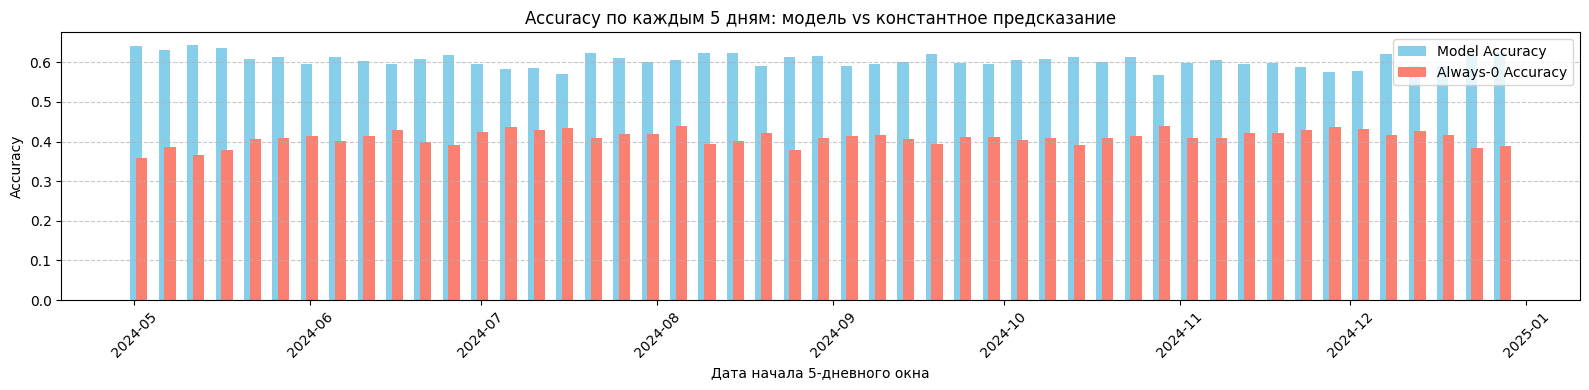

In [104]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# Загрузка и подготовка данных
data = pd.read_csv('../../generated_datasets/catboost_no_weights/Positive_short_valid.csv')
data['utc'] = pd.to_datetime(data['utc'])
data = data.sort_values('utc')

# Целевая переменная: будет ли close расти на следующей минуте
data['target'] = (data['close'].shift(-1) >= data['close']).astype(int)

# Предсказания модели
threshold = 0.5
data['pred'] = (data['predicted_proba'] > threshold).astype(int)

# Создаем группы по 5 дней
data['group_id'] = ((data['utc'] - data['utc'].min()).dt.days // 5)

# Функция для расчёта accuracy модели и accuracy "всегда 0"
def compute_group_accuracy(group):
    acc_model = accuracy_score(group['target'], group['pred'])
    acc_dummy0 = accuracy_score(group['target'], [0] * len(group))
    return pd.Series({'accuracy_model': acc_model, 'accuracy_dummy0': acc_dummy0})

# Применяем по группам
grouped_accuracy = data.groupby('group_id').apply(compute_group_accuracy).reset_index()

# Добавим дату начала группы
grouped_accuracy['start_date'] = data.groupby('group_id')['utc'].min().values

# Строим barplot
plt.figure(figsize=(16, 4))
bar_width = 4  # Ширина одного столбца (в днях на оси X)

# Координаты по оси X
x = grouped_accuracy['start_date']

# Столбцы с accuracy модели (слева) и dummy (чуть правее)
plt.bar(x, grouped_accuracy['accuracy_model'], 
        width=2, label='Model Accuracy', color='skyblue', align='center')

plt.bar(x, grouped_accuracy['accuracy_dummy0'], 
        width=2, label='Always-0 Accuracy', color='salmon', align='edge')

# Подписи и оформление
plt.title('Accuracy по каждым 5 дням: модель vs константное предсказание')
plt.xlabel('Дата начала 5-дневного окна')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

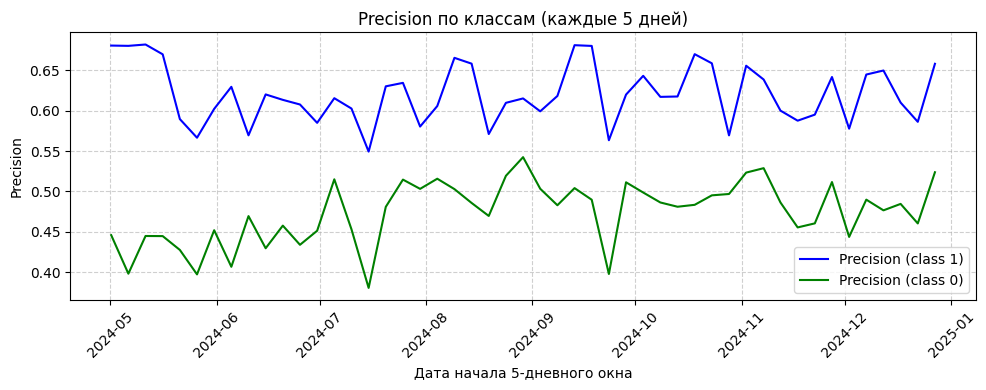

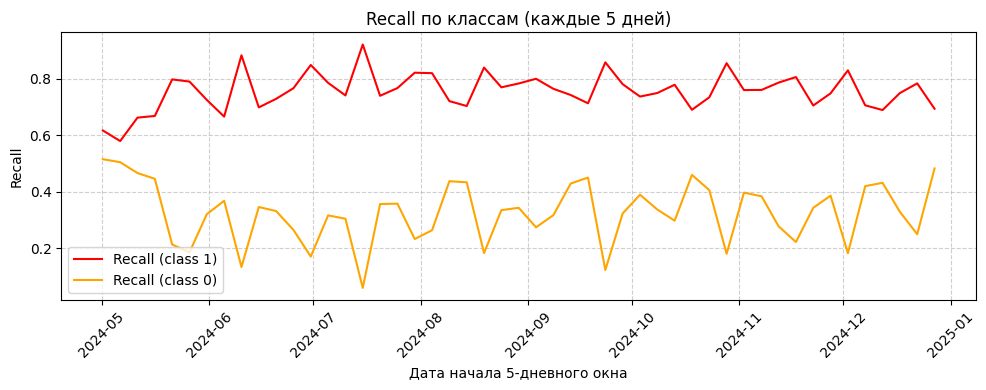

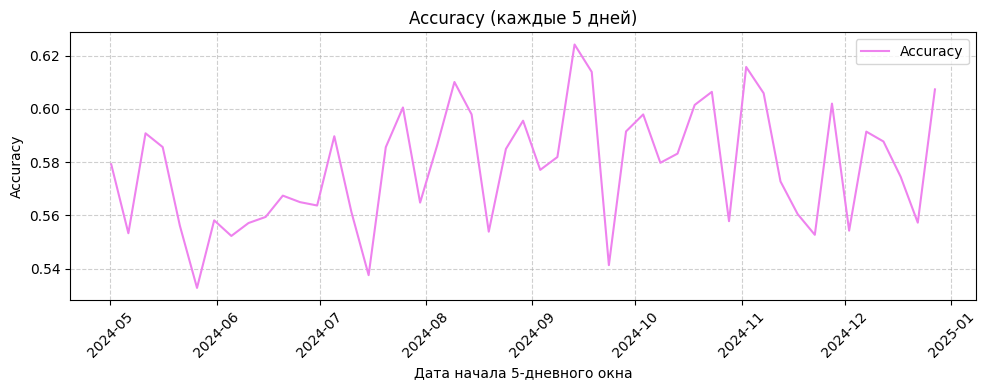

In [254]:
from sklearn.metrics import precision_score, recall_score, accuracy_score

# Загрузка и подготовка данных
data = pd.read_csv('../../generated_datasets/xgboost_with_weights/Gazprom_long_cat.csv')
data['utc'] = pd.to_datetime(data['utc'])
data = data.sort_values('utc')


# Целевая переменная: будет ли close расти на следующей минуте
data['target'] = (data['close'].shift(-1) >= data['close']).astype(int)

# Предсказания модели
threshold = 0.5
data['pred'] = (data['predicted_proba'] > threshold).astype(int)

# Создаем группы по 5 дней
data['group_id'] = ((data['utc'] - data['utc'].min()).dt.days // 5)


# Функция для расчета precision и recall по классам
def compute_precision_recall(group):
    y_true = group['target']
    y_pred = group['pred']
    accuracy = accuracy_score(y_true, y_pred)
    precision_1 = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
    precision_0 = precision_score(y_true, y_pred, pos_label=0, zero_division=0)
    recall_1 = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
    recall_0 = recall_score(y_true, y_pred, pos_label=0, zero_division=0)
    return pd.Series({
        'precision_1': precision_1,
        'precision_0': precision_0,
        'recall_1': recall_1,
        'recall_0': recall_0,
        'accuracy':  accuracy
    })

# Применяем по группам
metrics_by_group = data.groupby('group_id').apply(compute_precision_recall).reset_index()

# Добавим дату начала каждой группы
metrics_by_group['start_date'] = data.groupby('group_id')['utc'].min().values

# ----------------------- #
# 1. График Precision     #
# ----------------------- #
plt.figure(figsize=(10, 4))
plt.plot(metrics_by_group['start_date'], metrics_by_group['precision_1'], label='Precision (class 1)', color='blue')
plt.plot(metrics_by_group['start_date'], metrics_by_group['precision_0'], label='Precision (class 0)', color='green')
plt.title('Precision по классам (каждые 5 дней)')
plt.xlabel('Дата начала 5-дневного окна')
plt.ylabel('Precision')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ----------------------- #
# 2. График Recall        #
# ----------------------- #
plt.figure(figsize=(10, 4))
plt.plot(metrics_by_group['start_date'], metrics_by_group['recall_1'], label='Recall (class 1)', color='red')
plt.plot(metrics_by_group['start_date'], metrics_by_group['recall_0'], label='Recall (class 0)', color='orange')
plt.title('Recall по классам (каждые 5 дней)')
plt.xlabel('Дата начала 5-дневного окна')
plt.ylabel('Recall')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ----------------------- #
# 3. График Accuracy       #
# ----------------------- #
plt.figure(figsize=(10, 4))
plt.plot(metrics_by_group['start_date'], metrics_by_group['accuracy'], label='Accuracy', color='violet')
plt.title('Accuracy (каждые 5 дней)')
plt.xlabel('Дата начала 5-дневного окна')
plt.ylabel('Accuracy')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

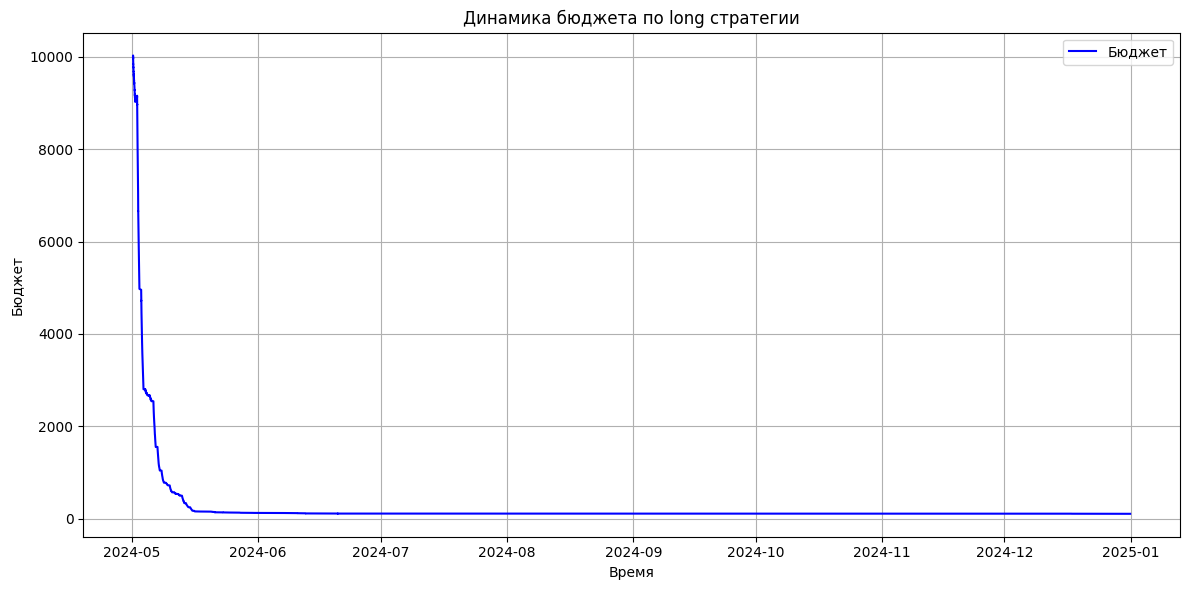

In [255]:
merged = data

# Добавим колонку close_{t+1}
merged['close_t+1'] = merged['close'].shift(-1)

df = merged

df['predicted_class'] = df['pred']

# Параметры
initial_budget = 10000
commission_rate = 0.0004

budget = initial_budget
budget_history = [budget]

budget_proba = initial_budget 
budget_proba_history = [budget]
timestamps = [df['utc'].iloc[0]]

for i in range(len(df) - 1):
    # continue
    row = df.iloc[i]
    next_row = df.iloc[i + 1]

    price_now = row['close']
    price_next = next_row['close']
    signal = row['predicted_class']
    proba = row['predicted_proba']

    if signal == 1:  # Long
        n_shares = int(budget // price_now)
        if n_shares == 0:
            pass
        else:
            buy_cost = n_shares * price_now * (1 + commission_rate)
            sell_revenue = n_shares * price_next * (1 - commission_rate)
            budget += (sell_revenue - buy_cost)
            

    # if signal == 0:  # Short
    #     n_shares = int(budget // price_now)
    #     if n_shares == 0:
    #         pass
    #     else:
    #         sell_proceeds = n_shares * price_now * (1 - commission_rate)
    #         buy_cost = n_shares * price_next * (1 + commission_rate)
    #         budget += sell_proceeds - buy_cost

    # Если signal == 0 — ничего не делаем
    budget_history.append(budget)
    timestamps.append(next_row['utc'])

# Визуализация
plt.figure(figsize=(12, 6))
plt.plot(timestamps, budget_history, label='Бюджет', color='blue')
plt.xlabel('Время')
plt.ylabel('Бюджет')
plt.title('Динамика бюджета по long стратегии')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Подбор гиперпараметров

In [94]:
import datetime as dt
from sklearn.metrics import precision_score, recall_score, fbeta_score
import optuna
import numpy as np
import xgboost as xgb

# ваши подготовка дата/фрейма здесь не меняется
company_name = 'Positive'
df_path = '../../datasets/' + company_name + '_1_min.csv'

start_time = dt.datetime(2024, 2, 1)
end_time = dt.datetime(2024, 4, 30)
cutoff_time = start_time - dt.timedelta(days=90)

findata = FinData(df_path)
findata.restrict_time_down(cutoff_time)
findata.restrict_time_up(end_time + dt.timedelta(days=2))
findata.insert_all()

cat_feats = findata.cat_features
num_feats = findata.numeric_features
target = 'direction_binary_0'

data = findata.df

def objective(trial):
    # weight_1 = trial.suggest_float("class_weight_1", 0.05, 1.0)
    depth = trial.suggest_int("max_depth", 2, 7)
    l2_lambda = trial.suggest_float("reg_lambda", 1e-5, 10.0, log=True)
    subsample = trial.suggest_float("subsample", 0.5, 1.0)

    params = {
        'n_estimators': 10000,
        'learning_rate': 0.02,
        'max_depth': depth,
        'subsample': subsample,
        'reg_lambda': l2_lambda,
        'objective': 'binary:logistic',
        'eval_metric': 'logloss',
        'random_state': 42,
        # 'scale_pos_weight': weight_1,  # для бэлансировки классов, если нужен другой mapping – переделайте
        'early_stopping_rounds': 500,
        'verbosity': 0,
        'tree_method': 'hist',         # ускоряет на больших выборках, может заменить на 'gpu_hist' если на GPU
    }

    curr_time = start_time
    f_betas = []

    while curr_time < end_time:
        train_df = data[(data.utc >= curr_time - dt.timedelta(days=35)) & (data.utc <= curr_time - dt.timedelta(days=5))]
        val_df = data[(data.utc > curr_time - dt.timedelta(days=5)) & (data.utc <= curr_time)]
        test_df = data[(data.utc > curr_time) & (data.utc <= curr_time + dt.timedelta(days=5))]
        if test_df.empty:
            break

        X_train, y_train = train_df[cat_feats + num_feats], train_df[target]
        X_val, y_val = val_df[cat_feats + num_feats], val_df[target]
        X_test, y_test = test_df[cat_feats + num_feats], test_df[target]

        model = xgb.XGBClassifier(**params)
        model.fit(
            X_train, y_train,
            eval_set=[(X_val, y_val)],
            verbose=False
        )

        proba = model.predict_proba(X_test)[:, 1]
        preds = (proba > 0.5).astype(int)
        f_betas.append(accuracy_score(y_test, preds))
        curr_time += dt.timedelta(days=5)

    final = np.mean(f_betas)
    return final

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=7)

print("Лучшие параметры:")
print(study.best_params)
print("Лучшее значение Accuracy:")
print(study.best_value)


[I 2025-07-07 11:42:32,128] A new study created in memory with name: no-name-344e46ac-4394-4e82-b10f-4d7f13e1329b
[I 2025-07-07 11:45:32,742] Trial 0 finished with value: 0.6195547182752397 and parameters: {'max_depth': 5, 'reg_lambda': 0.017183191903158552, 'subsample': 0.5538831779256554}. Best is trial 0 with value: 0.6195547182752397.
[I 2025-07-07 11:48:11,265] Trial 1 finished with value: 0.6208355631923055 and parameters: {'max_depth': 4, 'reg_lambda': 3.4307706592386844e-05, 'subsample': 0.6422323328645195}. Best is trial 1 with value: 0.6208355631923055.
[I 2025-07-07 11:50:44,302] Trial 2 finished with value: 0.6215356958327536 and parameters: {'max_depth': 5, 'reg_lambda': 0.0014622237975475412, 'subsample': 0.6140487891677724}. Best is trial 2 with value: 0.6215356958327536.
[I 2025-07-07 11:54:34,614] Trial 3 finished with value: 0.6199395337368159 and parameters: {'max_depth': 7, 'reg_lambda': 0.08456432711195264, 'subsample': 0.8691398623446053}. Best is trial 2 with val

Лучшие параметры:
{'max_depth': 5, 'reg_lambda': 0.0014622237975475412, 'subsample': 0.6140487891677724}
Лучшее значение Accuracy:
0.6215356958327536


In [95]:
import datetime as dt
from sklearn.metrics import precision_score, recall_score, fbeta_score
import optuna
import numpy as np
import xgboost as xgb

# ваши подготовка дата/фрейма здесь не меняется
company_name = 'Positive'
df_path = '../../datasets/' + company_name + '_1_min.csv'

start_time = dt.datetime(2024, 2, 1)
end_time = dt.datetime(2024, 4, 30)
cutoff_time = start_time - dt.timedelta(days=90)

findata = FinData(df_path)
findata.restrict_time_down(cutoff_time)
findata.restrict_time_up(end_time + dt.timedelta(days=2))
findata.insert_all()

cat_feats = findata.cat_features
num_feats = findata.numeric_features
target = 'direction_binary_1'

data = findata.df

def objective(trial):
    # weight_1 = trial.suggest_float("class_weight_1", 0.05, 1.0)
    depth = trial.suggest_int("max_depth", 2, 7)
    l2_lambda = trial.suggest_float("reg_lambda", 1e-5, 10.0, log=True)
    subsample = trial.suggest_float("subsample", 0.5, 1.0)

    params = {
        'n_estimators': 10000,
        'learning_rate': 0.02,
        'max_depth': depth,
        'subsample': subsample,
        'reg_lambda': l2_lambda,
        'objective': 'binary:logistic',
        'eval_metric': 'logloss',
        'random_state': 42,
        # 'scale_pos_weight': weight_1,  # для бэлансировки классов, если нужен другой mapping – переделайте
        'early_stopping_rounds': 500,
        'verbosity': 0,
        'tree_method': 'hist',         # ускоряет на больших выборках, может заменить на 'gpu_hist' если на GPU
    }

    curr_time = start_time
    f_betas = []

    while curr_time < end_time:
        train_df = data[(data.utc >= curr_time - dt.timedelta(days=35)) & (data.utc <= curr_time - dt.timedelta(days=5))]
        val_df = data[(data.utc > curr_time - dt.timedelta(days=5)) & (data.utc <= curr_time)]
        test_df = data[(data.utc > curr_time) & (data.utc <= curr_time + dt.timedelta(days=5))]
        if test_df.empty:
            break

        X_train, y_train = train_df[cat_feats + num_feats], train_df[target]
        X_val, y_val = val_df[cat_feats + num_feats], val_df[target]
        X_test, y_test = test_df[cat_feats + num_feats], test_df[target]

        model = xgb.XGBClassifier(**params)
        model.fit(
            X_train, y_train,
            eval_set=[(X_val, y_val)],
            verbose=False
        )

        proba = model.predict_proba(X_test)[:, 1]
        preds = (proba > 0.5).astype(int)
        f_betas.append(accuracy_score(y_test, preds))
        curr_time += dt.timedelta(days=5)

    final = np.mean(f_betas)
    return final

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=7)

print("Лучшие параметры:")
print(study.best_params)
print("Лучшее значение Accuracy:")
print(study.best_value)


[I 2025-07-07 12:03:10,926] A new study created in memory with name: no-name-abcaa524-dd13-48b0-b869-08d0356bef5a
[I 2025-07-07 12:05:39,594] Trial 0 finished with value: 0.6307098965982187 and parameters: {'max_depth': 2, 'reg_lambda': 4.410552298914929, 'subsample': 0.8583698348524449}. Best is trial 0 with value: 0.6307098965982187.
[I 2025-07-07 12:09:28,753] Trial 1 finished with value: 0.6298915670899431 and parameters: {'max_depth': 7, 'reg_lambda': 0.00014302655445839476, 'subsample': 0.7939785064191295}. Best is trial 0 with value: 0.6307098965982187.
[I 2025-07-07 12:11:35,736] Trial 2 finished with value: 0.6313904701467759 and parameters: {'max_depth': 4, 'reg_lambda': 2.7104871141112006, 'subsample': 0.5416983059345823}. Best is trial 2 with value: 0.6313904701467759.
[I 2025-07-07 12:14:11,123] Trial 3 finished with value: 0.631403700172711 and parameters: {'max_depth': 5, 'reg_lambda': 0.013598674829772646, 'subsample': 0.783901194830491}. Best is trial 3 with value: 0.6

Лучшие параметры:
{'max_depth': 5, 'reg_lambda': 0.0001639426541478026, 'subsample': 0.8573438390431201}
Лучшее значение Accuracy:
0.6316929222592189


In [191]:
def true_positive(y_pred, close, commission):
    return ((y_pred == 1) & (close.shift(-1) / close > 1 + commission)).sum()

def true_negative(y_pred, close, commission):
    return ((y_pred == 0) & (close.shift(-1) / close <= 1 + commission)).sum()

def false_positive(y_pred, close, commission):
    return ((y_pred == 1) & (close.shift(-1) / close <= 1 + commission)).sum()

def false_negative(y_pred, close, commission):
    return ((y_pred == 0) & (close.shift(-1) / close > 1 + commission)).sum()

def accuracy_long(y_pred, close, commission):
    tp = true_positive(y_pred, close, commission)
    fp = false_positive(y_pred, close, commission)
    tn = true_negative(y_pred, close, commission)
    fn = false_negative(y_pred, close, commission)
    return (tp + fp) / (tp + fp + tn + fn)

def precision_long(y_pred, close, commission):
    tp = true_positive(y_pred, close, commission)
    fp = false_positive(y_pred, close, commission)
    return tp / (tp + fp) if (tp + fp) > 0 else 0

def recall_long(y_pred, close, commission):
    tp = true_positive(y_pred, close, commission)
    fn = false_negative(y_pred, close, commission)
    return tp / (tp + fn) if (tp + fn) > 0 else 0

def f1_metric_long(y_pred, close, commission, beta = 0.005):
    pr = precision_long(y_pred, close, commission)
    rec = recall_long(y_pred, close, commission)
    return (1 + beta * beta) * pr * rec / (beta * beta * pr + rec) if (beta * beta * pr + rec) > 0 else 0

In [194]:
def true_positive_short(y_pred, close, commission):
    return ((y_pred == 1) & (close / close.shift(-1) < 1 + commission)).sum() # P = 1: close / close.shift(-1) < 1 + commission

def true_negative_short(y_pred, close, commission):
    return ((y_pred == 0) & (close / close.shift(-1) >= 1 + commission)).sum() # N = 0 : close / close.shift(-1) >= 1 + commission 

def false_positive_short(y_pred, close, commission):
    return ((y_pred == 1) & (close / close.shift(-1) >= 1 + commission)).sum()

def false_negative_short(y_pred, close, commission):
    return ((y_pred == 0) & (close / close.shift(-1) < 1 + commission)).sum()

def accuracy_short(y_pred, close, commission):
    tp = true_positive_short(y_pred, close, commission)
    fp = false_positive_short(y_pred, close, commission)
    tn = true_negative_short(y_pred, close, commission)
    fn = false_negative_short(y_pred, close, commission)
    return (tp + fp) / (tp + fp + tn + fn)

def precision_short(y_pred, close, commission):
    tn = true_negative_short(y_pred, close, commission)
    fn = false_negative_short(y_pred, close, commission)
    return tn / (tn + fn) if (tn + fn) > 0 else 0

def recall_short(y_pred, close, commission):
    tn = true_negative_short(y_pred, close, commission)
    fp = false_positive_short(y_pred, close, commission)
    return tn / (tn + fp) if (tn + fp) > 0 else 0

def f1_metric_short(y_pred, close, commission, beta=0.005):
    pr = precision_short(y_pred, close, commission)
    rec = recall_short(y_pred, close, commission)
    return (1 + beta * beta) * pr * rec / (beta * beta * pr + rec) if (beta * beta * pr + rec) > 0 else 0

In [ ]:
import pandas as pd
import glob
from sklearn.metrics import accuracy_score, precision_score, recall_score, fbeta_score

all_summary_dict = dict()
commission_rate = 0.0008
b = 0.005



for model_type in ['catboost', 'lightgbm', 'xgboost']:
    csv_paths = glob.glob(f'../../generated_datasets/{model_type}_no_weights/*.csv')  # или свой путь


    for path in csv_paths:
        df = pd.read_csv(path)

        name = path.split('/')[-1].split('_')[0]
        if name not in all_summary_dict:
            all_summary_dict[name] = []

        y_true_l = (df['close'].shift(-1) > df['close']).astype(int)
        y_true_s = (df['close'].shift(-1) >= df['close']).astype(int)
        y_true_long = (df['close'].shift(-1) >= df['close'] + commission_rate * (df['close'] + df['close'].shift(-1))).astype(int)
        y_true_short = 1 - (df['close'] >= df['close'].shift(-1) + commission_rate * (df['close'] + df['close'].shift(-1))).astype(int)

        threshold = 0.5
        y_pred = (df['predicted_proba'] > threshold).astype(int)
        fname = path.split('/')[-1].split('_')[0] + '_' + path.split('/')[-1].split('_')[1] + '_' + model_type
        if path.split('/')[-1].split('_')[1] == 'long':
            accuracy = accuracy_score(y_true_l, y_pred)
            y_true = y_true_l
        else:
            accuracy = accuracy_score(y_true_s, y_pred)
            y_true = y_true_s
        
        if path.split('/')[-1].split('_')[1] == 'long':
            accuracy2 = accuracy_score(y_true_long, y_pred)
            # accuracy2 = accuracy_long(y_pred, df['close'], commission_rate)
        else:
            accuracy2 = accuracy_score(y_true_short, y_pred)

        precisions = precision_score(y_true, y_pred, average=None, labels=[0,1])
        recalls = recall_score(y_true, y_pred, average=None, labels=[0,1])
        fbetas = fbeta_score(y_true, y_pred, beta=0.0001, average=None, labels=[0,1])
        if path.split('/')[-1].split('_')[1] == 'long':
            fbetas_w_comm =  f1_metric_long(y_pred, df['close'], commission_rate, beta=b)
            pr_w = precision_long(y_pred, df['close'], commission_rate)
            re_w = recall_long(y_pred, df['close'], commission_rate)
        else:
            fbetas_w_comm =  f1_metric_short(y_pred, df['close'], commission_rate, beta=b)
            pr_w = precision_short(y_pred, df['close'], commission_rate)
            re_w = recall_short(y_pred, df['close'], commission_rate)

        row = {
            'file': fname,
            'accuracy': accuracy,
            'accuracy_': accuracy2,
            'pr_w': pr_w,
            're_w': re_w,
            'f_beta_w': fbetas_w_comm,
            'f_beta': fbetas[1],
            # 'f_beta_short': fbetas_short[0],
        }
        all_summary_dict[name].append(row)

for model_type in ['catboost', 'lightgbm', 'xgboost']:
    csv_paths = glob.glob(f'../../generated_datasets/{model_type}_with_weights/*.csv')  # или свой путь


    for path in csv_paths:
        df = pd.read_csv(path)

        name = path.split('/')[-1].split('_')[0]
        if name not in all_summary_dict:
            all_summary_dict[name] = []

        y_true_l = (df['close'].shift(-1) > df['close']).astype(int)
        y_true_s = (df['close'].shift(-1) >= df['close']).astype(int)
        y_true_long = (df['close'].shift(-1) >= df['close'] + commission_rate * (df['close'] + df['close'].shift(-1))).astype(int)
        y_true_short = 1 - (df['close'] >= df['close'].shift(-1) + commission_rate * (df['close'] + df['close'].shift(-1))).astype(int)

        threshold = 0.5
        y_pred = (df['predicted_proba'] > threshold).astype(int)
        fname = path.split('/')[-1].split('_')[0] + '_' + path.split('/')[-1].split('_')[1] + '_' + model_type + '_w'
        if path.split('/')[-1].split('_')[1] == 'long':
            accuracy = accuracy_score(y_true_l, y_pred)
            y_true = y_true_l
        else:
            accuracy = accuracy_score(y_true_s, y_pred)
            y_true = y_true_s
        
        if path.split('/')[-1].split('_')[1] == 'long':
            accuracy2 = accuracy_score(y_true_long, y_pred)
            # accuracy2 = accuracy_long(y_pred, df['close'], commission_rate)
        else:
            accuracy2 = accuracy_score(y_true_short, y_pred)

        precisions = precision_score(y_true, y_pred, average=None, labels=[0,1])
        recalls = recall_score(y_true, y_pred, average=None, labels=[0,1])
        fbetas = fbeta_score(y_true, y_pred, beta=0.0001, average=None, labels=[0,1])
        if path.split('/')[-1].split('_')[1] == 'long':
            fbetas_w_comm =  fbeta_metric_long(y_pred, df['close'], commission_rate, beta=b)
            pr_w = precision_long(y_pred, df['close'], commission_rate)
            re_w = recall_long(y_pred, df['close'], commission_rate)
        else:
            fbetas_w_comm =  fbeta_metric_short(y_pred, df['close'], commission_rate, beta=b)
            pr_w = precision_short(y_pred, df['close'], commission_rate)
            re_w = recall_short(y_pred, df['close'], commission_rate)

        row = {
            'file': fname,
            'accuracy': accuracy,
            'accuracy_': accuracy2,
            'pr_w': pr_w,
            're_w': re_w,
            'f_beta_w': fbetas_w_comm,
            'f_beta': fbetas[1],
            # 'f_beta_short': fbetas_short[0],
        }
        all_summary_dict[name].append(row)

# Делаем итоговую таблицу (индексация по имени файла)

all_df_dict = dict()

for name in all_summary_dict.keys():
    all_df_dict[name] = pd.DataFrame(all_summary_dict[name]).set_index('file')

all_df_dict['Positive']


NameError: name 'f1_metric_short' is not defined